In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import random
from tqdm.notebook import tqdm as tqdm
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches

In [2]:
device="cpu" 

In [3]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [4]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [5]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

In [6]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [7]:
input_length = 256

np.random.seed(0)
n_samples_train = 100000

periods_train = np.random.uniform(200, 2000, n_samples_train)

x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

x_train = torch.tensor(np.concatenate([x_sin, x_saw, x_tri, x_square], axis=0), dtype=torch.float32)
shapes_train = np.arange(n_samples_train) // (n_samples_train//4)

In [8]:
AE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
AE.load_state_dict(torch.load("beta_zero.pth"))
good_VAE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
good_VAE.load_state_dict(torch.load("beta_zerooneeight.pth"))
BAE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
BAE.load_state_dict(torch.load("beta_zerotwo.pth"))

<All keys matched successfully>

In [9]:
shuffle_indices = np.random.permutation(np.arange(n_samples_train))

x_train_shuffle = x_train[shuffle_indices]
shapes_train_shuffle = shapes_train[shuffle_indices]
periods_train_shuffle = periods_train[shuffle_indices]

In [10]:
x = AE.encoder(x_train_shuffle)
z_mean, z_log_var = AE.z_mean(x), AE.z_log_var(x)
AE_encoded_orig = AE.reparameterize(z_mean, z_log_var).detach().numpy()

In [11]:
x = good_VAE.encoder(x_train_shuffle)
z_mean, z_log_var = good_VAE.z_mean(x), good_VAE.z_log_var(x)
good_AE_encoded_orig = good_VAE.reparameterize(z_mean, z_log_var).detach().numpy()

In [12]:
x = BAE.encoder(x_train_shuffle)
z_mean, z_log_var = BAE.z_mean(x), BAE.z_log_var(x)
BAE_encoded_orig = BAE.reparameterize(z_mean, z_log_var).detach().numpy()

2024-10-07 21:11:42.390 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-10-07 21:11:43.493 
  command:

    streamlit run C:\Users\pkodu\AppData\Local\anaconda3\envs\PCPT\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2024-10-07 21:11:43.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-10-07 21:11:43.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-10-07 21:11:43.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-10-07 21:11:43.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-10-07 21:11:43.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-10-07 21:11:43.498

DeltaGenerator()

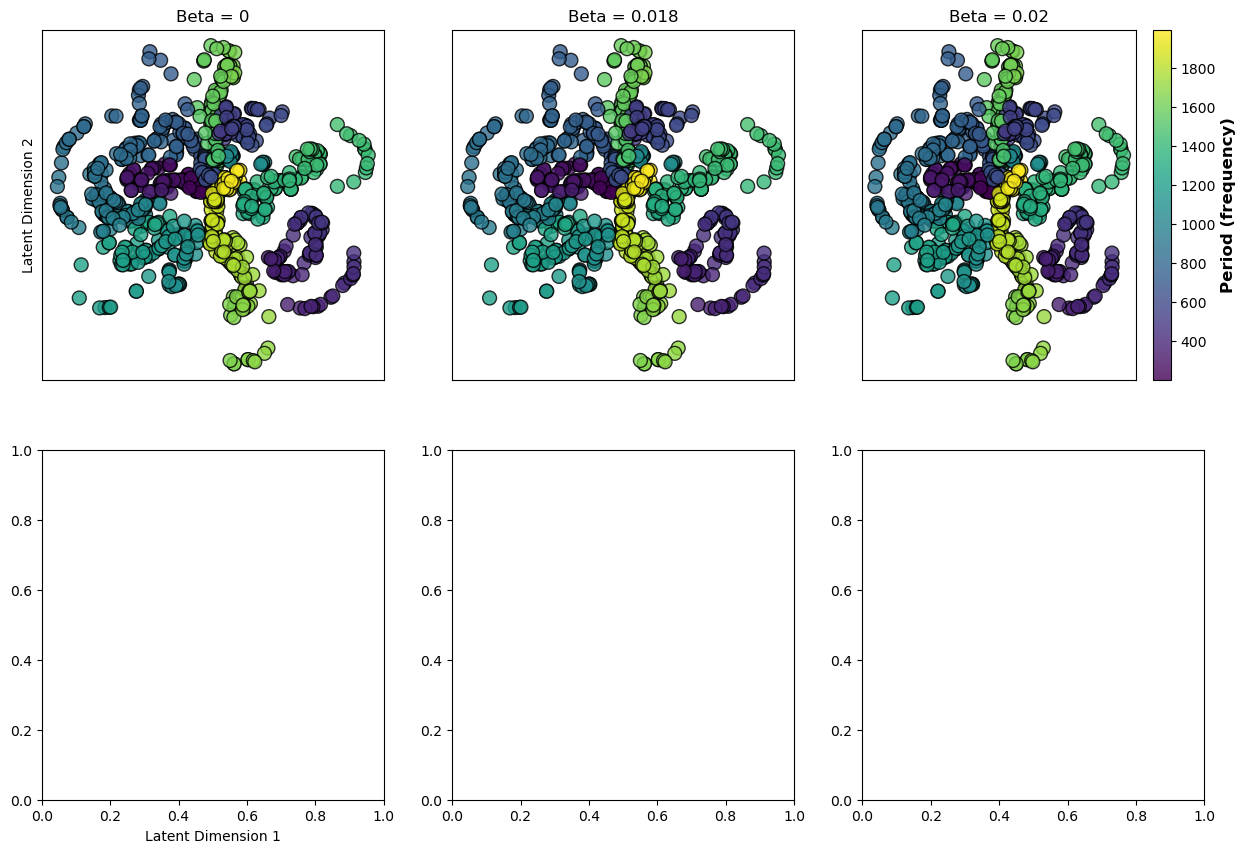

In [13]:
# Encoded data for each model
import streamlit as st
import torch
import numpy as np
import matplotlib.pyplot as plt
def encode_model(model):
    x = model.encoder(x_train_shuffle)
    z_mean, z_log_var = model.z_mean(x), model.z_log_var(x)
    return model.reparameterize(z_mean, z_log_var).detach().numpy()

AE_encoded_orig = encode_model(AE)
good_AE_encoded_orig = encode_model(good_VAE)
BAE_encoded_orig = encode_model(BAE)

# Plotting function
def create_scatter(ax, encoded_orig, color_data, add_colorbar=False, character="frequency"):
    scatter = ax.scatter(encoded_orig[:1000, 0], encoded_orig[:1000, 1], 
                         c=color_data[:1000], cmap='viridis', alpha=0.8, 
                         edgecolors='k', s=100, marker='o')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    if add_colorbar:
        if character == "shape":
            cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2, 3])
            cbar.ax.set_yticklabels(["sin", "saw", "tri", "square"])
            cbar.set_label('Shapes', fontsize=12, fontweight='bold')
        else:
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Period (frequency)', fontsize=12, fontweight='bold')

# Streamlit UI
st.title("VAE Latent Space Visualization")
beta_value = st.slider("Select Beta Value", 0.0, 0.02, step=0.018)
plot_type = st.radio("Plot Type", ["Period", "Shape"])

# Select the correct model based on the slider
if beta_value == 0.0:
    encoded_orig = AE_encoded_orig
elif beta_value == 0.018:
    encoded_orig = good_AE_encoded_orig
else:
    encoded_orig = BAE_encoded_orig

# Create the plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

if plot_type == "Period":
    create_scatter(axes[0, 0], encoded_orig, periods_train_shuffle)
    create_scatter(axes[0, 1], encoded_orig, periods_train_shuffle)
    create_scatter(axes[0, 2], encoded_orig, periods_train_shuffle, add_colorbar=True)
else:
    create_scatter(axes[1, 0], encoded_orig, shapes_train_shuffle, character="shape")
    create_scatter(axes[1, 1], encoded_orig, shapes_train_shuffle, character="shape")
    create_scatter(axes[1, 2], encoded_orig, shapes_train_shuffle, add_colorbar=True, character="shape")

axes[0, 0].set_title("Beta = 0")
axes[0, 1].set_title("Beta = 0.018")
axes[0, 2].set_title("Beta = 0.02")

axes[1, 0].set_xlabel("Latent Dimension 1")
axes[0, 0].set_ylabel("Latent Dimension 2")

st.pyplot(fig)